In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from pathlib import Path

import processed.train as T


DEVICE = torch.device("cpu")

ck = torch.load(
    "processed/best.pt",
    map_location=DEVICE,
    weights_only=False
)

model = T.build_model()
model.load_state_dict(ck["state_dict"])
model.eval()

print("Model loaded.")

Model loaded.


In [6]:
def dice_score(pred, gt, label):
    pred_mask = pred == label
    gt_mask = gt == label

    intersection = np.logical_and(pred_mask, gt_mask).sum()

    denom = pred_mask.sum() + gt_mask.sum()

    if denom == 0:
        return np.nan

    return 2.0 * intersection / denom

def dice_per_label(pred, gt):
    return {
        f"L{label}": dice_score(pred, gt, label)
        for label in range(1, 6)
    }

def plot_case(img, gt, pred, case_id):
    
    views = {
        "Sagittal": 1,
        "Coronal": 2,
        "Axial": 0,
    }

    fig, ax = plt.subplots(3, 3, figsize=(13, 12))

    for row, (view_name, axis) in enumerate(views.items()):

        if axis == 0:
            ct = img[img.shape[0] // 2, :, :]
            gt_slice = gt[gt.shape[0] // 2, :, :]
            pred_slice = pred[pred.shape[0] // 2, :, :]

        elif axis == 1:
            ct = img[:, img.shape[1] // 2, :]
            gt_slice = gt[:, gt.shape[1] // 2, :]
            pred_slice = pred[:, pred.shape[1] // 2, :]

        else:
            ct = img[:, :, img.shape[2] // 2]
            gt_slice = gt[:, :, gt.shape[2] // 2]
            pred_slice = pred[:, :, pred.shape[2] // 2]

        # Transpose for display
        ct = ct.T
        gt_slice = gt_slice.T
        pred_slice = pred_slice.T

        ax[row, 0].imshow(
            ct,
            cmap="gray",
            origin="lower"
        )
        ax[row, 0].set_title(f"{view_name} – CT")

        ax[row, 1].imshow(
            ct,
            cmap="gray",
            origin="lower"
        )

        gt_mask = np.ma.masked_where(
            gt_slice == 0,
            gt_slice
        )

        ax[row, 1].imshow(
            gt_mask,
            cmap="jet",
            vmin=1,
            vmax=5,
            alpha=0.5,
            origin="lower"
        )

        ax[row, 1].set_title(f"{view_name} – Ground Truth")

        ax[row, 2].imshow(
            ct,
            cmap="gray",
            origin="lower"
        )

        pred_mask = np.ma.masked_where(
            pred_slice == 0,
            pred_slice
        )

        ax[row, 2].imshow(
            pred_mask,
            cmap="jet",
            vmin=1,
            vmax=5,
            alpha=0.5,
            origin="lower"
        )

        ax[row, 2].set_title(f"{view_name} – Prediction")

        for a in ax[row]:
            a.axis("off")

    fig.suptitle(
        f"{case_id} — L1–L5 segmentation",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

Dice:
L1: 0.725
L2: 0.905
L3: 0.938
L4: 0.942
L5: 0.922


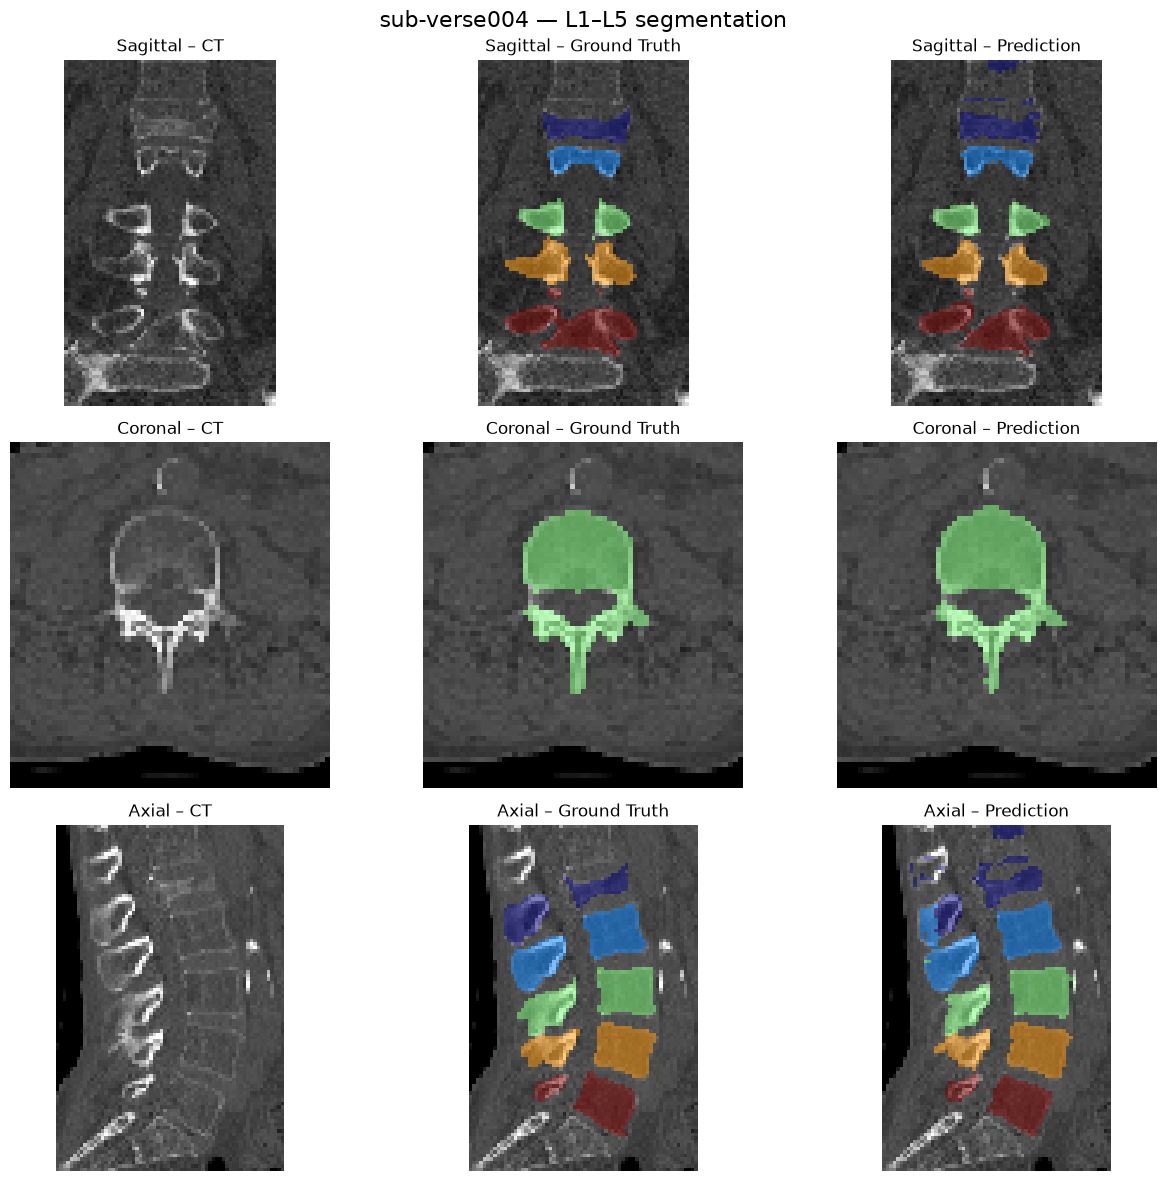

In [23]:
case_id = "sub-verse004"

img, lab = T.load_case(
    Path(f"processed/verse/{case_id}")
)

pred = T.predict_volume(
    model,
    img,
    DEVICE
)

print("Dice:")
for label, score in dice_per_label(pred, lab).items():
    print(f"{label}: {score:.3f}")

plot_case(img, lab, pred, case_id)

In [24]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

import processed.train as T

DEVICE = torch.device("cpu")

ck = torch.load(
    "processed/best.pt",
    map_location=DEVICE,
    weights_only=False
)

model = T.build_model()
model.load_state_dict(ck["state_dict"])
model.eval()


def plot_segmentation(case_id, dataset="verse"):
    case_dir = Path("processed") / dataset / case_id

    img, gt = T.load_case(case_dir)
    pred = T.predict_volume(model, img, DEVICE)

    fig, ax = plt.subplots(1, 3, figsize=(13, 6))

    for a, mask, title in zip(
        ax,
        [None, gt, pred],
        ["CT", "Ground Truth", "Prediction"]
    ):
        a.imshow(
            img.max(0).T,
            cmap="gray",
            origin="lower"
        )

        if mask is not None:
            overlay = np.ma.masked_where(
                mask.max(0).T == 0,
                mask.max(0).T
            )

            a.imshow(
                overlay,
                cmap="jet",
                vmin=1,
                vmax=5,
                alpha=0.5,
                origin="lower"
            )

        a.set_title(title)
        a.axis("off")

    fig.suptitle(case_id)
    plt.tight_layout()
    plt.show()

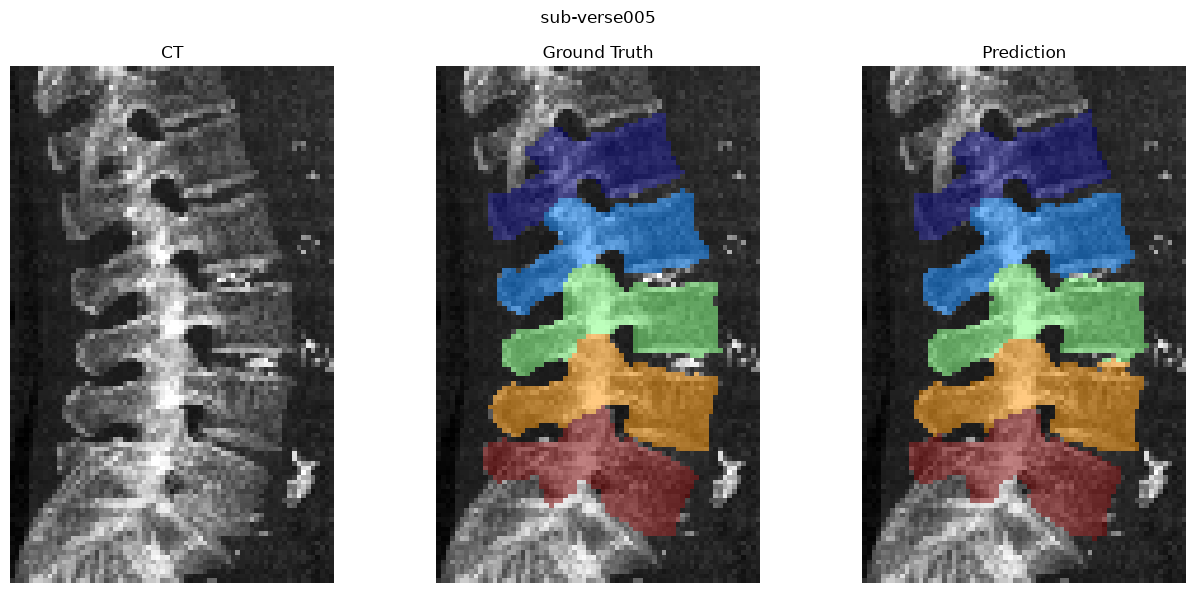

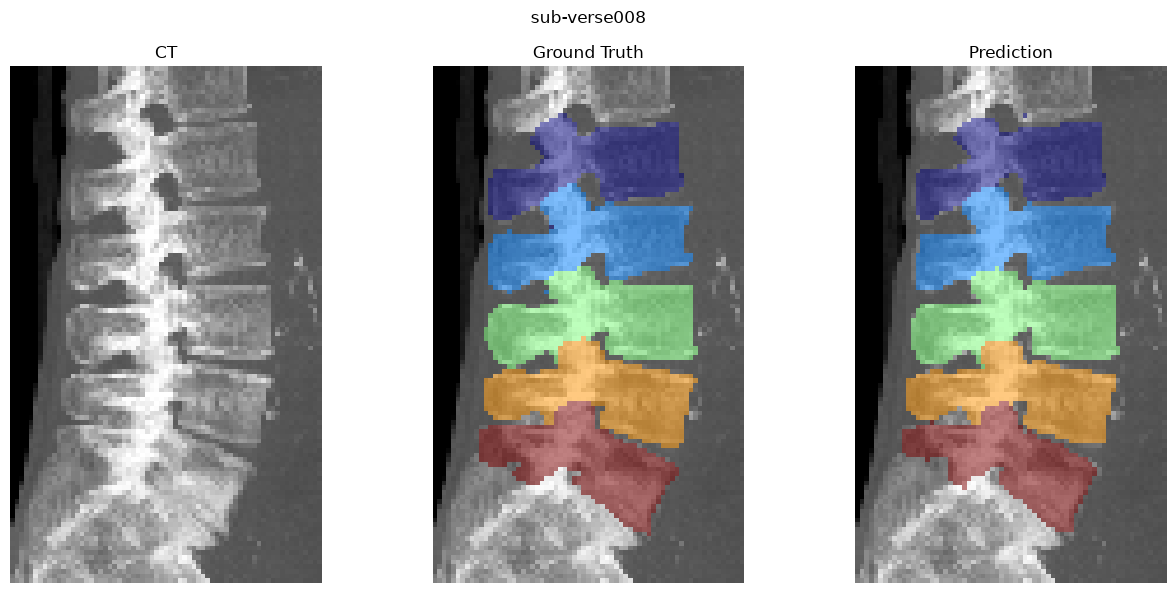

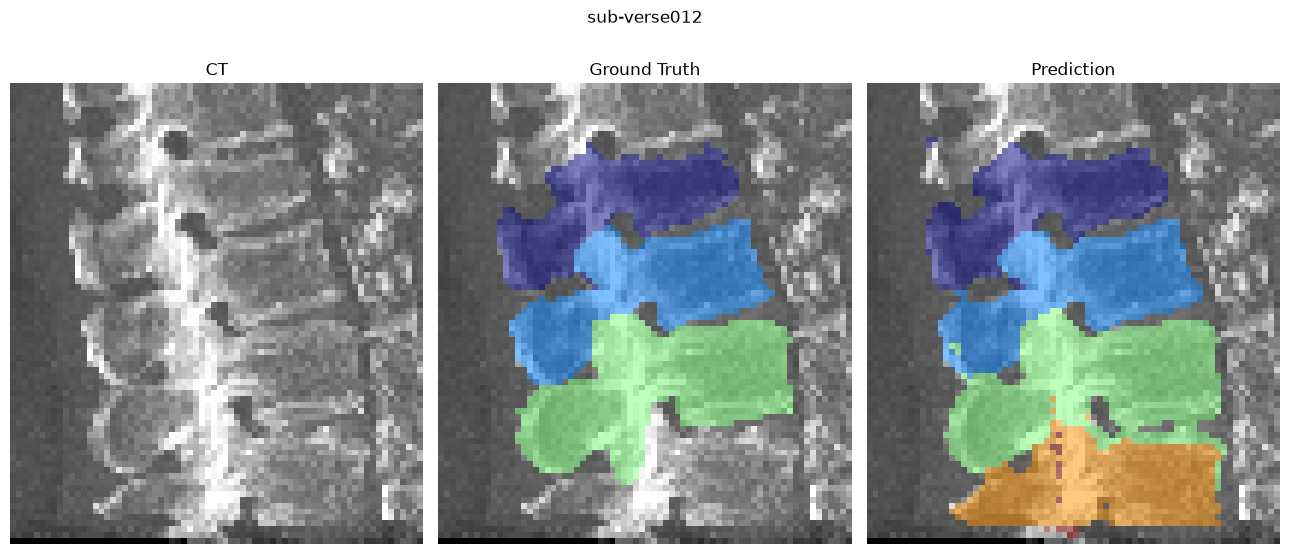

In [27]:
for case_id in ["sub-verse005", "sub-verse008", "sub-verse012"]:
    plot_segmentation(case_id)